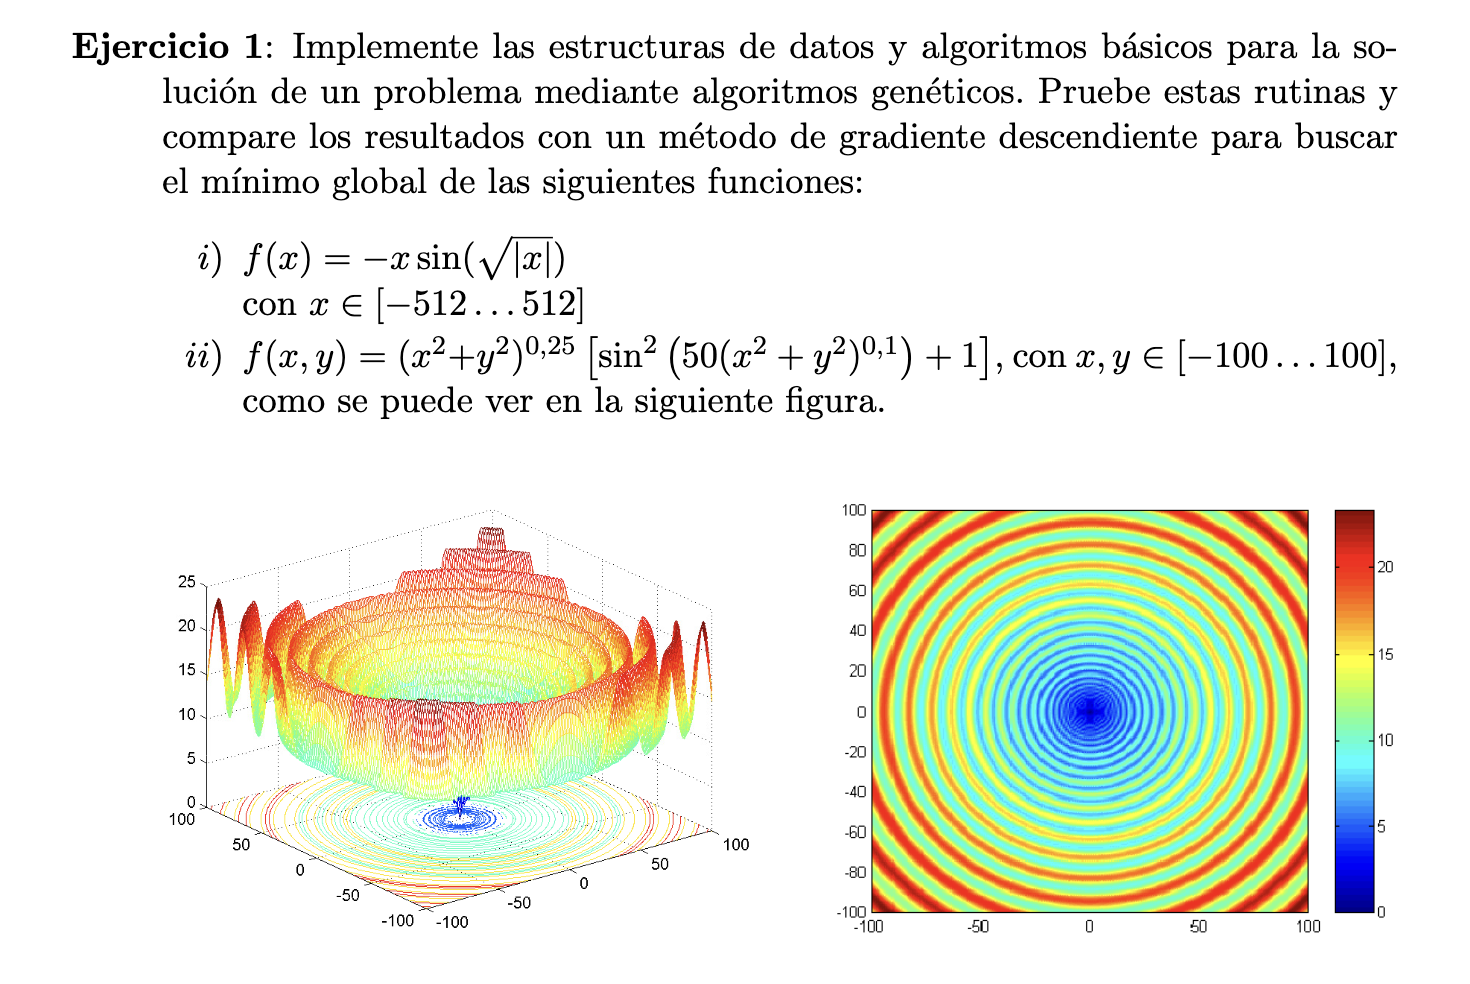

In [85]:
import math
import random

def funcion(x, y = None):
    if y == None:
        return -x*math.sin(math.sqrt(abs(x))) #[-512, 512] minimo: -418.98
    else:
        return ((x**2 + y**2)**0.25)*(math.sin(50*((x**2 + y**2)**0.1))**2 + 1) #[-100,100] minimo = 0

def evaluar(poblacion, ej):
    aptitudes = []
    for i in poblacion:
        if ej == 2:
            aptitudes.append(funcion(i[0], i[1]))
        else:
            aptitudes.append(funcion(i))
    return aptitudes

def seleccion(poblacion, k = 2):
    idx_padres = []
    idx_madres = []
    
    for i in range(k):
        idx_padres.append(random.randrange(len(poblacion)))
        idx_madres.append(random.randrange(len(poblacion)))

    idx_padre = idx_padres[0]
    idx_madre = idx_madres[0]

    for i in range(k):
        if aptitudes[idx_padres[i]] < aptitudes[idx_padre]:
            idx_padre = idx_padres[i]

        if aptitudes[idx_madres[i]] < aptitudes[idx_madre]:
            idx_madre = idx_madres[i]
    
    return poblacion[idx_padre], poblacion[idx_madre]

def real_a_binario(z):
    if isinstance(z, (int, float)):
        x = round(z)
        entero = x + 512
        bits = format(entero, '010b')
        return bits
    else:
        x = round(z[0])
        y = round(z[1])
        entero_x = x + 100
        entero_y = y + 100
        bits_x = format(entero_x, '08b')
        bits_y = format(entero_y, '08b')
        return bits_x + bits_y

def cruce(padre, madre):
    corte = random.randint(1, len(padre) - 1)
    hijo = padre[:corte] + madre[corte:]
    return hijo

def mutacion(hijo_binario, probabilidad = 0.1):
    adn = list(hijo_binario)
    for i in range(len(adn)):
        if random.random() < probabilidad:
            if adn[i] == '1':
                adn[i] = '0'
            else:
                adn[i] = '1'
    hijo_mutado = ''.join(adn)
    return hijo_mutado

def binario_a_real(hijo_mutado):
    if len(hijo_mutado) == 10:
        entero = int(hijo_mutado, 2)
        x = entero - 512
        return x

    else:
        mitad = len(hijo_mutado) // 2

        bits_x = hijo_mutado[:mitad]
        bits_y = hijo_mutado[mitad:]

        entero_x = int(bits_x, 2)
        entero_y = int(bits_y, 2)

        if entero_x > 200 or entero_y > 200:
            hijo_mutado = mutacion(hijo_mutado)
            return binario_a_real(hijo_mutado)

        x = entero_x - 100
        y = entero_y - 100

        return x, y
    
def creacion(poblacion, ej = None):
    padre, madre = seleccion(poblacion)
    if ej == None:
        hijo = cruce(padre, madre)
        hijo_mutado = mutacion(hijo)
        return hijo_mutado
    else:
        padre_binario = real_a_binario(padre)
        madre_binario = real_a_binario(madre)
        hijo_binario = cruce(padre_binario, madre_binario)
        hijo_mutado = mutacion(hijo_binario)
        hijo = binario_a_real(hijo_mutado)
    return hijo


In [86]:

ej = 1
tamañoPoblacion = 20
print("Tamaño de la población:", tamañoPoblacion)

poblacion = []

if ej == 1:
    aptitudRequerida = -418.98

    for i in range(tamañoPoblacion):
    
        poblacion.append(random.uniform(-512, 512))
   
else:
    aptitudRequerida = 0

    for i in range(tamañoPoblacion):
    
        x = random.uniform(-100, 100)
        y = random.uniform(-100, 100)
        poblacion.append((x, y))



#evaluar poblacion
aptitudes = evaluar(poblacion, ej)

#mejor aptitud
mejorAptitud = min(aptitudes)

generacion = 0
while True:
    generacion = generacion + 1
    #reemplazo generacional
    hijos = []
    for i in range(tamañoPoblacion):
        hijos.append(creacion(poblacion, ej))

    poblacion = hijos
    
    #evaluar poblacion
    aptitudes = evaluar(poblacion, ej)
    mejorAptitud = min(aptitudes)
    print("Generacion:",generacion)
    print("mejorAptitud:", mejorAptitud)
    
    if mejorAptitud <= aptitudRequerida:
        break

    
    

    

Tamaño de la población: 20
Generacion: 1
mejorAptitud: -408.6971087411776
Generacion: 2
mejorAptitud: -416.99998938753396
Generacion: 3
mejorAptitud: -416.99998938753396
Generacion: 4
mejorAptitud: -416.99998938753396
Generacion: 5
mejorAptitud: -417.8725384273932
Generacion: 6
mejorAptitud: -418.49427060384335
Generacion: 7
mejorAptitud: -370.0648344490838
Generacion: 8
mejorAptitud: -397.62898713247876
Generacion: 9
mejorAptitud: -418.8486470214627
Generacion: 10
mejorAptitud: -383.414660856447
Generacion: 11
mejorAptitud: -418.8486470214627
Generacion: 12
mejorAptitud: -391.1922135362046
Generacion: 13
mejorAptitud: -418.8486470214627
Generacion: 14
mejorAptitud: -418.46195611258617
Generacion: 15
mejorAptitud: -391.1922135362046
Generacion: 16
mejorAptitud: -391.1922135362046
Generacion: 17
mejorAptitud: -418.8486470214627
Generacion: 18
mejorAptitud: -417.8725384273932
Generacion: 19
mejorAptitud: -414.5058791934804
Generacion: 20
mejorAptitud: -411.0203477479716
Generacion: 21
me

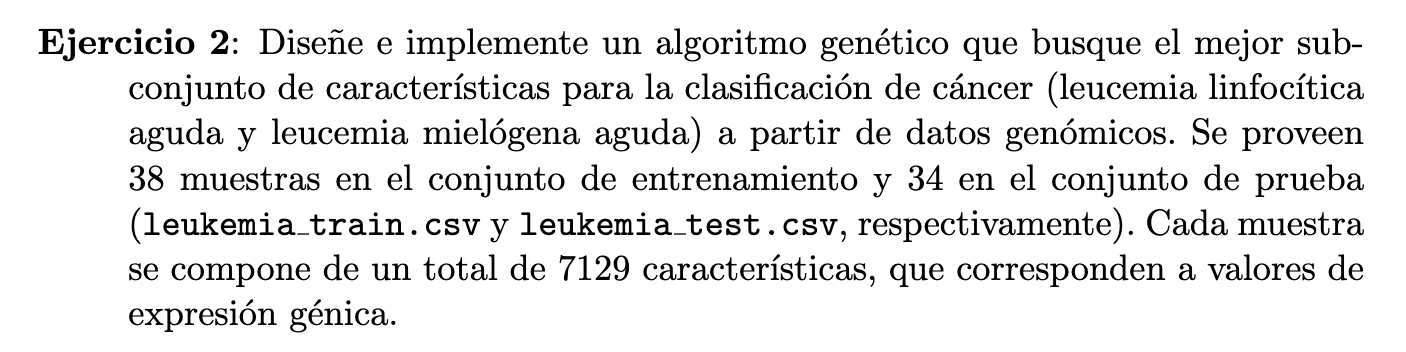

In [87]:
import pandas as pd

train = pd.read_csv("leukemia_train.csv")
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

test = pd.read_csv("leukemia_test.csv")
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

cantidadGenes = len(train.columns) - 1



def aplicar_mascara(individuo, X):

    columnas = []

    for i in range(len(individuo)):

        if individuo[i] == '1':
            columnas.append(i)

    return X.iloc[:, columnas]

def distancia(a, b):

    suma = 0

    for i in range(len(a)):
        suma += (a[i] - b[i]) ** 2

    return math.sqrt(suma)

def entrenar_lvq(X, y, epocas=20, tasa=0.1):

    X = X.values
    y = y.values

    prototipos = []
    clases = [0, 1]

    for clase in clases:

        indices = []

        for i in range(len(y)):
            if y[i] == clase:
                indices.append(i)

        indice = random.choice(indices)

        prototipos.append(X[indice].copy())

    # Entrenamiento
    for epoca in range(epocas):

        for i in range(len(X)):

            patron = X[i]
            clase = y[i]

            distancias = []

            for j in range(len(prototipos)):

                d = distancia(patron, prototipos[j])
                distancias.append(d)

            indice_ganador = distancias.index(min(distancias))

            if clases[indice_ganador] == clase:

                for j in range(len(patron)):
                    prototipos[indice_ganador][j] += tasa * (patron[j] - prototipos[indice_ganador][j])

            else:

                for j in range(len(patron)):
                    prototipos[indice_ganador][j] -= tasa * (patron[j] - prototipos[indice_ganador][j])

        tasa = tasa * 0.95

    return prototipos, clases


def predecir_lvq(X, prototipos, clases):

    X = X.values

    predicciones = []

    for muestra in X:

        distancias = []

        for prototipo in prototipos:

            d = distancia(muestra, prototipo)
            distancias.append(d)

        indice_ganador = distancias.index(min(distancias))

        predicciones.append(clases[indice_ganador])

    return predicciones

def evaluar_individuo(individuo):

    #entrenar
    X_seleccionado = aplicar_mascara(individuo, X_train)
    prototipos, clases = entrenar_lvq(X_seleccionado,y_train)

    #predecir
    X_seleccionado = aplicar_mascara(individuo, X_test)
    predicciones = predecir_lvq(X_seleccionado,prototipos,clases)
    aciertos = 0

    for i in range(len(y_test)):
        if predicciones[i] == y_test.iloc[i]:
            aciertos = aciertos + 1

    aptitud = aciertos / len(y_test)

    return aptitud


In [88]:

poblacion = []
for i in range(tamañoPoblacion):
    individuo = []
    for j in range(cantidadGenes):
        individuo.append(str(random.randint(0, 1)))
    poblacion.append(individuo)


aptitudRequerida = 0.95
aptitudes = []
for individuo in poblacion:
    aptitud = evaluar_individuo(individuo)
    aptitudes.append(aptitud)

mejorAptitud = max(aptitudes)

generacion = 0
while True:
    generacion = generacion + 1
    #reemplazo generacional
    hijos = []
    for i in range(tamañoPoblacion):
        hijos.append(creacion(poblacion))

    poblacion = hijos
    
    #evaluar poblacion
    aptitudes = []
    for individuo in poblacion:
        aptitud = evaluar_individuo(individuo)
        aptitudes.append(aptitud)
    
    mejorAptitud = max(aptitudes)
    indiceMejor = aptitudes.index(mejorAptitud)

    print("Generacion:", generacion)
    print("Mejor individuo:", indiceMejor)
    print("Mejor aptitud:", mejorAptitud)
    
    if mejorAptitud >= aptitudRequerida:
        break

Generacion: 1
Mejor individuo: 5
Mejor aptitud: 0.9696969696969697
